In [1]:
# ================================================================
#  NASA C-MAPSS — AŞAMA 2B
#  Aşama 2A'dan fark:
#    Bi-LSTM mimarisi değişti → Attention Gate eklendi
#    MSCNNTransformer → 2A checkpoint'inden yüklenir (değişmedi)
#    GRU Meta → sıfırdan eğitilir (yeni Bi-LSTM preds geliyor)
#
#  Neden Attention Gate?
#    Aşama 1 ve 2A'da Bi-LSTM sadece son timestep'i (h30)
#    kullanıyordu. h1..h29 bilgisi çöpe gidiyordu.
#
#    Attention Gate:
#      e_t  = tanh(W · h_t + b)     ← her timestep skoru
#      α_t  = softmax(e_t)           ← normalize et
#      c    = Σ α_t · h_t            ← ağırlıklı ortalama
#
#    Sonuç: model "hangi döngü daha önemli?" sorusunu
#    kendisi öğreniyor. Motor bozulmadan 10 döngü önce
#    s11'de ani artış olduysa — model orayı ağır basar.
#
#    Ekstra: α_t ağırlıkları görselleştirilebilir →
#    "Motor X'te epoch 18 kritikti" diyebilirsin.
#    Bu Aşama 2C SHAP ile birleşince XAI katkısı olur.
#
#  Checkpoint stratejisi:
#    Bi-LSTM+Attn : sıfırdan eğit (yeni mimari)
#    MSCNNTransf  : 2A checkpoint'inden yükle
#    OOF Bi-LSTM  : yeniden hesapla (mimari değişti)
#    OOF MSCNN    : 2A cache'inden yükle
#    GRU Meta     : sıfırdan eğit
# ================================================================

In [2]:
# ================================================================
#  NASA C-MAPSS — AŞAMA 2B (DÜZELTİLMİŞ)
#  BiLSTM+Attention + ClusterNorm + Transformer(A1) → GRU Meta
#
#  Düzeltmeler:
#    1. predict_batched → GPU memory sorunu çözüldü
#    2. OOF fold bazında cluster normalization
#    3. train_meta imzası düzeltildi
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, warnings, os, zipfile, copy, json
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_RUL = 125
SEQ_LEN = 30

print(f"Cihaz : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

from google.colab import drive
drive.mount('/content/drive')

A1_CKPT_ROOT  = '/content/drive/MyDrive/cmapss_checkpoints/asama1'
A2B_CKPT_ROOT = '/content/drive/MyDrive/cmapss_checkpoints/asama2b'
SAVE_ROOT     = '/content/drive/MyDrive/cmapss_asama2b'
os.makedirs(A2B_CKPT_ROOT, exist_ok=True)
os.makedirs(SAVE_ROOT,     exist_ok=True)

Cihaz : cuda
GPU   : NVIDIA L4
VRAM  : 23.7 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 1 — Batched Inference (GPU Memory Fix)   ║
# ╚══════════════════════════════════════════════════╝

def predict_batched(model, X_np, batch=512):
    """
    Tüm X'i bir seferde GPU'ya yüklemek yerine
    batch batch tahmin yapar. FD002/FD004 gibi
    büyük test setlerinde GPU memory hatasını önler.
    """
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch):
            xb = torch.tensor(X_np[i:i+batch]).to(DEVICE)
            preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)

In [4]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 2 — Veri & Cluster Normalization         ║
# ╚══════════════════════════════════════════════════╝

DATA_DIR = '/content/CMAPSSData'
if not os.path.exists(DATA_DIR):
    OUTER_ZIP = '/content/drive/MyDrive/TurbofanEğitimi/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'
    with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
        z.extractall('/content/outer_zip')
    inner_zip = None
    for root, dirs, files in os.walk('/content/outer_zip'):
        for f in files:
            if f.endswith('.zip'): inner_zip = os.path.join(root, f)
    with zipfile.ZipFile(inner_zip, 'r') as z:
        z.extractall(DATA_DIR)
    print("✓ Veri çıkarıldı")

COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
OP_COLS = ['op1','op2','op3']

FEAT_COLS_MAP = {
    'FD001': ['op3','s2','s3','s4','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD002': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
    'FD003': ['op3','s2','s3','s4','s6','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD004': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
}

# FD001/FD003 → 1 koşul (normal MinMax)
# FD002/FD004 → 6 koşul (Cluster Norm)
N_CLUSTERS = {'FD001': 1, 'FD002': 6, 'FD003': 1, 'FD004': 6}


def fit_cluster_scalers(df, feat_cols, kmeans):
    """Train fold üzerinde her cluster için scaler fit et."""
    labels  = kmeans.predict(df[OP_COLS].values)
    df      = df.copy()
    df['_cl'] = labels
    scalers = {}
    for c in range(kmeans.n_clusters):
        mask = df['_cl'] == c
        if mask.sum() == 0: continue
        sc = MinMaxScaler()
        df.loc[mask, feat_cols] = sc.fit_transform(df.loc[mask, feat_cols])
        scalers[c] = sc
    df.drop(columns=['_cl'], inplace=True)
    return df, labels, scalers


def apply_cluster_scalers(df, feat_cols, kmeans, scalers):
    """Önceden fit edilmiş scalerları uygula."""
    labels    = kmeans.predict(df[OP_COLS].values)
    df        = df.copy()
    df['_cl'] = labels
    for c, sc in scalers.items():
        mask = df['_cl'] == c
        if mask.sum() == 0: continue
        df.loc[mask, feat_cols] = sc.transform(df.loc[mask, feat_cols])
    df.drop(columns=['_cl'], inplace=True)
    return df


def cluster_normalize_full(train_df, test_df, feat_cols, subset):
    """
    Tüm train/test için normalizasyon.
    FD001/FD003: Normal MinMax.
    FD002/FD004: K-Means cluster bazında MinMax.
    """
    n_cl = N_CLUSTERS[subset]
    if n_cl == 1:
        sc = MinMaxScaler()
        train_df = train_df.copy(); test_df = test_df.copy()
        train_df[feat_cols] = sc.fit_transform(train_df[feat_cols])
        test_df[feat_cols]  = sc.transform(test_df[feat_cols])
        return train_df, test_df, None

    kmeans = KMeans(n_clusters=n_cl, random_state=SEED, n_init=10)
    kmeans.fit(train_df[OP_COLS].values)
    train_df, tr_labels, scalers = fit_cluster_scalers(train_df, feat_cols, kmeans)
    test_df = apply_cluster_scalers(test_df, feat_cols, kmeans, scalers)

    dist = [f"C{c}={int((tr_labels==c).sum())}" for c in range(n_cl)]
    print(f"  Cluster dağılımı: {', '.join(dist)}")
    return train_df, test_df, kmeans


def make_sequences(df, feat_cols):
    X, y = [], []
    for _, g in df.groupby('unit'):
        g = g.sort_values('cycle')
        v = g[feat_cols].values
        r = g['rul'].values
        for i in range(len(v) - SEQ_LEN + 1):
            X.append(v[i:i+SEQ_LEN]); y.append(r[i+SEQ_LEN-1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def load_and_prepare(subset):
    feat_cols = FEAT_COLS_MAP[subset]
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')

    mc = train.groupby('unit')['cycle'].max()
    train['rul'] = (train['unit'].map(mc) - train['cycle']).clip(0, MAX_RUL)

    last = test.groupby('unit').last().reset_index()
    last['final_rul'] = rul['rul'].values
    lc = test.groupby('unit')['cycle'].max().reset_index()
    lc.columns = ['unit','last_cycle']
    test = test.merge(last[['unit','final_rul']], on='unit', how='left')
    test = test.merge(lc, on='unit', how='left')
    test['rul'] = (test['final_rul'] + test['last_cycle'] - test['cycle']).clip(0, MAX_RUL)
    test.drop(columns=['final_rul','last_cycle'], inplace=True)

    # Raw df'i OOF için sakla (normalize edilmemiş)
    train_raw = train.copy()

    print(f"  [{subset}] Cluster norm ({N_CLUSTERS[subset]} koşul)...")
    train_norm, test_norm, kmeans = cluster_normalize_full(
        train, test, feat_cols, subset)

    X_tr, y_tr = make_sequences(train_norm, feat_cols)
    X_te, y_te = make_sequences(test_norm,  feat_cols)

    print(f"  [{subset}] Train: {X_tr.shape} | Test: {X_te.shape}")
    return {
        'subset':    subset,
        'n_feat':    len(feat_cols),
        'feat_cols': feat_cols,
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_te': X_te, 'y_te': y_te,
        'train_raw': train_raw,  # OOF fold normalizasyonu için
        'kmeans':    kmeans,
    }

def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1).sum())

def get_metrics(y_true, y_pred):
    return {
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'R2':    float(r2_score(y_true, y_pred)),
        'Score': nasa_score(y_true, y_pred),
    }

✓ Veri çıkarıldı


In [5]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 3 — Early Stopping                       ║
# ╚══════════════════════════════════════════════════╝

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.05):
        self.patience=patience; self.min_delta=min_delta
        self.counter=0; self.best_rmse=float('inf')
        self.best_state=None; self.best_ep=0

    def step(self, rmse, model, epoch):
        if rmse < self.best_rmse - self.min_delta:
            self.best_rmse=rmse
            self.best_state=copy.deepcopy(model.state_dict())
            self.best_ep=epoch; self.counter=0; return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state: model.load_state_dict(self.best_state)
        return model

In [6]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 4 — Checkpoint                           ║
# ╚══════════════════════════════════════════════════╝

def save_ckpt(model, metrics, name, subset, ckpt_dir):
    os.makedirs(ckpt_dir, exist_ok=True)
    pt = os.path.join(ckpt_dir, f'{name}_{subset}.pt')
    torch.save(model.state_dict(), pt)
    meta = {k: v for k, v in metrics.items() if k != 'history'}
    with open(pt.replace('.pt','.json'), 'w') as f: json.dump(meta, f, indent=2)
    print(f"  ✓ Checkpoint → {pt}")

def load_ckpt(model, name, subset, ckpt_dir):
    pt = os.path.join(ckpt_dir, f'{name}_{subset}.pt')
    js = pt.replace('.pt', '.json')
    if not os.path.exists(pt):
        print(f"  ⚠ Checkpoint yok: {pt}"); return model, None
    model.load_state_dict(torch.load(pt, map_location=DEVICE))
    model = model.to(DEVICE)
    m = json.load(open(js)) if os.path.exists(js) else None
    if m: print(f"  ✓ {name}_{subset}: RMSE={m.get('RMSE',0):.3f}  R²={m.get('R2',0):.4f}")
    return model, m

def ckpt_ok(name, subset, ckpt_dir):
    return os.path.exists(os.path.join(ckpt_dir, f'{name}_{subset}.pt'))

def oof_ok(name, subset, ckpt_dir):
    return os.path.exists(os.path.join(ckpt_dir, f'oof_{name}_{subset}.npy'))

In [7]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 5 — Model Mimarileri                     ║
# ╚══════════════════════════════════════════════════╝

class BiLSTMAttention(nn.Module):
    """
    Bi-LSTM + Attention Gate
    α_t = softmax(tanh(W·h_t))
    c   = Σ α_t · h_t
    """
    def __init__(self, n_feat, hidden=256, layers=3, dropout=0.30):
        super().__init__()
        self.lstm   = nn.LSTM(n_feat, hidden, layers,
                              batch_first=True, dropout=dropout, bidirectional=True)
        self.norm   = nn.LayerNorm(hidden * 2)
        self.attn_w = nn.Linear(hidden * 2, 1, bias=True)
        self.fc     = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _  = self.lstm(x)
        out     = self.norm(out)
        alpha   = F.softmax(torch.tanh(self.attn_w(out)), dim=1)
        ctx     = (alpha * out).sum(dim=1)
        return self.fc(ctx).squeeze()

    def get_attention_weights(self, x):
        self.eval()
        with torch.no_grad():
            out, _ = self.lstm(x); out = self.norm(out)
            alpha  = F.softmax(torch.tanh(self.attn_w(out)), dim=1)
        return alpha.squeeze(-1).cpu().numpy()


class TransformerRUL(nn.Module):
    """Aşama 1 ile aynı — checkpoint yüklenir."""
    def __init__(self, n_feat, d_model=128, nhead=4, layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc    = nn.Parameter(torch.randn(1, SEQ_LEN, d_model)*0.01)
        enc = nn.TransformerEncoderLayer(d_model, nhead, 256, dropout,
                                          batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        x = self.input_proj(x) + self.pos_enc
        return self.fc(self.transformer(x)[:, -1]).squeeze()


class GRUMetaModel(nn.Module):
    def __init__(self, n_feat, gru_hidden=64):
        super().__init__()
        self.gru       = nn.GRU(n_feat, gru_hidden, 1, batch_first=True)
        self.pred_proj = nn.Sequential(nn.Linear(2, 16), nn.ReLU())
        self.fusion    = nn.Sequential(
            nn.Linear(gru_hidden+16, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x, p1, p2):
        _, h = self.gru(x); ctx = h.squeeze(0)
        pf   = self.pred_proj(torch.stack([p1, p2], dim=1))
        return self.fusion(torch.cat([ctx, pf], dim=1)).squeeze()

In [8]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 6 — Base Model Eğitimi                   ║
# ╚══════════════════════════════════════════════════╝

def train_base(model, data, max_ep=200, lr=1e-3, batch=256,
               patience=15, name='', ck_name=None, ck_dir=None, force=False):
    subset = data['subset']

    if ck_name and ck_dir and not force and ckpt_ok(ck_name, subset, ck_dir):
        print(f"\n  [{name}] Checkpoint → yükleniyor")
        model, saved = load_ckpt(model, ck_name, subset, ck_dir)
        preds = predict_batched(model, data['X_te'])
        m = get_metrics(data['y_te'], preds)
        m['best_ep'] = saved.get('best_ep','?') if saved else '?'
        m['history'] = {'epoch':[],'rmse':[],'r2':[]}
        return m, preds, model

    model  = model.to(DEVICE)
    loader = DataLoader(
        TensorDataset(torch.tensor(data['X_tr']), torch.tensor(data['y_tr'])),
        batch, shuffle=True)
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',0.5,10,min_lr=1e-6)
    crit = nn.HuberLoss(delta=10.0)
    es   = EarlyStopping(patience=patience)
    hist = {'epoch':[],'rmse':[],'r2':[]}
    t0   = time.time()
    np_  = sum(p.numel() for p in model.parameters())

    print(f"\n{'─'*62}")
    print(f"  {name} | max {max_ep} ep | patience={patience} | {np_:,} param")
    print(f"{'─'*62}")

    for ep in range(1, max_ep+1):
        model.train(); losses=[]
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss=crit(model(xb),yb)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); losses.append(loss.item())

        preds = predict_batched(model, data['X_te'])
        rmse  = float(np.sqrt(mean_squared_error(data['y_te'], preds)))
        r2    = float(r2_score(data['y_te'], preds))
        sch.step(rmse)
        hist['epoch'].append(ep); hist['rmse'].append(rmse); hist['r2'].append(r2)

        if ep%10==0 or ep==1:
            print(f"  Ep {ep:4d}/{max_ep}  Loss={np.mean(losses):8.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  "
                  f"lr={opt.param_groups[0]['lr']:.2e}  ES={es.counter}/{patience}")

        if es.step(rmse, model, ep):
            print(f"\n  ⚡ Early Stop ep {ep} | Best ep {es.best_ep} RMSE={es.best_rmse:.3f}")
            break

    model = es.restore(model)
    preds = predict_batched(model, data['X_te'])
    elapsed = time.time()-t0
    m = get_metrics(data['y_te'], preds)
    m['Time']=elapsed; m['history']=hist; m['best_ep']=es.best_ep
    print(f"\n  ✓ {name}: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({elapsed/60:.1f} dk | ep={es.best_ep})")
    if ck_name and ck_dir: save_ckpt(model, m, ck_name, subset, ck_dir)
    return m, preds, model

In [9]:
def get_oof(ModelClass, model_kwargs, data,
            n_splits=5, max_ep=150, lr=1e-3, batch=256,
            patience=15, name='', ck_name=None, ck_dir=None, force=False):

    subset    = data['subset']
    feat_cols = data['feat_cols']
    kmeans    = data['kmeans']
    train_raw = data['train_raw']

    if ck_name and ck_dir and not force and oof_ok(ck_name, subset, ck_dir):
        op = os.path.join(ck_dir, f'oof_{ck_name}_{subset}.npy')
        print(f"\n  [{name}] OOF cache → yükleniyor")
        oof = np.load(op)
        print(f"  OOF RMSE: {float(np.sqrt(mean_squared_error(data['y_tr'],oof))):.3f}")
        return oof

    print(f"\n  [{name}] OOF — {n_splits} fold (max {max_ep} ep, patience={patience})")

    y_all = data['y_tr']
    oof   = np.zeros(len(y_all), dtype=np.float32)

    # Unit listesi ve unit→sekans eşlemesi
    units = train_raw['unit'].unique()
    unit_of_seq = []
    for uid, g in train_raw.groupby('unit'):
        cnt = max(0, len(g) - SEQ_LEN + 1)
        unit_of_seq.extend([uid] * cnt)
    unit_of_seq = np.array(unit_of_seq)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold, (tr_u_idx, va_u_idx) in enumerate(kf.split(units)):
        tr_units = units[tr_u_idx]
        va_units = units[va_u_idx]

        # Bu unit'lere ait sekans indekslerini bul
        tr_seq_idx = np.where(np.isin(unit_of_seq, tr_units))[0]
        va_seq_idx = np.where(np.isin(unit_of_seq, va_units))[0]

        # Ham df'ten fold verisi
        tr_df = train_raw[train_raw['unit'].isin(tr_units)].copy()
        va_df = train_raw[train_raw['unit'].isin(va_units)].copy()

        # Fold bazında normalize
        if kmeans is not None:
            tr_df, _, fold_sc = fit_cluster_scalers(tr_df, feat_cols, kmeans)
            va_df = apply_cluster_scalers(va_df, feat_cols, kmeans, fold_sc)
        else:
            sc = MinMaxScaler()
            tr_df[feat_cols] = sc.fit_transform(tr_df[feat_cols])
            va_df[feat_cols] = sc.transform(va_df[feat_cols])

        Xtr, ytr = make_sequences(tr_df, feat_cols)
        Xva, yva = make_sequences(va_df, feat_cols)

        mdl  = ModelClass(**model_kwargs).to(DEVICE)
        opt  = torch.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-4)
        sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                   opt, 'min', 0.5, 8, min_lr=1e-6)
        crit = nn.HuberLoss(delta=10.0)
        es   = EarlyStopping(patience=patience)
        dl   = DataLoader(
            TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
            batch, shuffle=True)

        for ep in range(max_ep):
            mdl.train()
            for xb, yb in dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); loss = crit(mdl(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
                opt.step()
            vp    = predict_batched(mdl, Xva)
            vrmse = float(np.sqrt(mean_squared_error(yva, vp)))
            sch.step(vrmse)
            if es.step(vrmse, mdl, ep+1): break

        mdl    = es.restore(mdl)
        fold_p = predict_batched(mdl, Xva)

        # Doğrudan sekans indeksine yaz — boyut garantili
        oof[va_seq_idx] = fold_p

        fold_rmse = float(np.sqrt(mean_squared_error(yva, fold_p)))
        print(f"  Fold {fold+1}/{n_splits}  RMSE={fold_rmse:.3f}  (ep {es.best_ep})")
        del mdl; torch.cuda.empty_cache()

    oof_rmse = float(np.sqrt(mean_squared_error(y_all, oof)))
    print(f"  [{name}] OOF RMSE: {oof_rmse:.3f}")

    if ck_name and ck_dir:
        op = os.path.join(ck_dir, f'oof_{ck_name}_{subset}.npy')
        os.makedirs(ck_dir, exist_ok=True)
        np.save(op, oof)
        print(f"  ✓ OOF kaydedildi")
    return oof

In [10]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 8 — GRU Meta Eğitimi                     ║
# ╚══════════════════════════════════════════════════╝

def train_meta(meta, data, oof_bl, oof_tf, bl_preds, tf_preds,
               max_ep=100, lr=5e-4, batch=256, patience=20,
               ck_name='meta', ck_dir=None, force=False):
    subset = data['subset']

    def meta_batched_pred(meta, X, bl, tf, batch=512):
        meta.eval(); preds=[]
        X_t=torch.tensor(X); bl_t=torch.tensor(bl); tf_t=torch.tensor(tf)
        with torch.no_grad():
            for i in range(0, len(X), batch):
                xb=X_t[i:i+batch].to(DEVICE)
                b1=bl_t[i:i+batch].to(DEVICE)
                b2=tf_t[i:i+batch].to(DEVICE)
                preds.append(meta(xb,b1,b2).cpu().numpy())
        return np.concatenate(preds)

    if ck_name and ck_dir and not force and ckpt_ok(ck_name, subset, ck_dir):
        print(f"\n  [Meta] Checkpoint → yükleniyor")
        meta, saved = load_ckpt(meta, ck_name, subset, ck_dir)
        preds = meta_batched_pred(meta, data['X_te'], bl_preds, tf_preds)
        m = get_metrics(data['y_te'], preds)
        m['best_ep']=saved.get('best_ep','?') if saved else '?'
        m['history']={'epoch':[],'rmse':[],'r2':[]}
        print(f"  Meta: RMSE={m['RMSE']:.3f}")
        return m, preds

    meta   = meta.to(DEVICE)
    loader = DataLoader(
        TensorDataset(
            torch.tensor(data['X_tr']), torch.tensor(oof_bl),
            torch.tensor(oof_tf),       torch.tensor(data['y_tr'])
        ), batch, shuffle=True)
    opt  = torch.optim.AdamW(meta.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',0.5,8,min_lr=1e-6)
    crit = nn.HuberLoss(delta=10.0)
    es   = EarlyStopping(patience=patience, min_delta=0.02)
    hist = {'epoch':[],'rmse':[],'r2':[]}
    t0   = time.time()
    np_  = sum(p.numel() for p in meta.parameters())

    print(f"\n{'─'*62}")
    print(f"  GRU Meta | {subset} | max {max_ep} ep | {np_:,} param")
    print(f"{'─'*62}")

    for ep in range(1, max_ep+1):
        meta.train(); losses=[]
        for xb,b1,b2,yb in loader:
            xb,b1,b2,yb = xb.to(DEVICE),b1.to(DEVICE),b2.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(); loss=crit(meta(xb,b1,b2),yb)
            loss.backward(); nn.utils.clip_grad_norm_(meta.parameters(),1.0)
            opt.step(); losses.append(loss.item())

        preds = meta_batched_pred(meta, data['X_te'], bl_preds, tf_preds)
        rmse  = float(np.sqrt(mean_squared_error(data['y_te'], preds)))
        r2    = float(r2_score(data['y_te'], preds))
        sch.step(rmse)
        hist['epoch'].append(ep); hist['rmse'].append(rmse); hist['r2'].append(r2)

        if ep%5==0 or ep==1:
            print(f"  Ep {ep:3d}/{max_ep}  Loss={np.mean(losses):7.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  ES={es.counter}/{patience}")

        if es.step(rmse, meta, ep):
            print(f"\n  ⚡ Early Stop ep {ep} | Best ep {es.best_ep} RMSE={es.best_rmse:.3f}")
            break

    meta  = es.restore(meta)
    best_p= meta_batched_pred(meta, data['X_te'], bl_preds, tf_preds)
    elapsed = time.time()-t0
    m = get_metrics(data['y_te'], best_p)
    m['Time']=elapsed; m['history']=hist; m['best_ep']=es.best_ep
    print(f"\n  ✓ Meta: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({elapsed/60:.1f} dk | ep={es.best_ep})")
    if ck_name and ck_dir: save_ckpt(meta, m, ck_name, subset, ck_dir)
    return m, best_p

In [11]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 9 — Attention Isı Haritası               ║
# ╚══════════════════════════════════════════════════╝

def plot_attention_heatmap(model, data, subset, save_dir, n=6):
    model=model.to(DEVICE); model.eval()
    X_te=data['X_te']; y_te=data['y_te']
    n=min(n,len(X_te))
    idx=np.linspace(0,len(X_te)-1,n,dtype=int)
    X_s=torch.tensor(X_te[idx]).to(DEVICE)
    attn=model.get_attention_weights(X_s)

    fig,axes=plt.subplots(n,1,figsize=(14,2.5*n),facecolor='#0a0e1a')
    if n==1: axes=[axes]
    for i,ax in enumerate(axes):
        ax.set_facecolor('#0d1421')
        w=attn[i]; rul=y_te[idx[i]]
        im=ax.imshow(w[np.newaxis,:],aspect='auto',cmap='YlOrRd',vmin=0,vmax=w.max())
        ax.set_yticks([])
        ax.set_xticks(range(SEQ_LEN))
        ax.set_xticklabels([str(t+1) if (t+1)%5==0 else '' for t in range(SEQ_LEN)],
                           color='white',fontsize=9)
        ax.set_title(f'Motor {i+1}  |  Gerçek RUL={rul:.0f}  |  '
                     f'En kritik döngü: {np.argmax(w)+1}',
                     color='white',fontsize=10,fontweight='bold')
        plt.colorbar(im,ax=ax,fraction=0.02,pad=0.02)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    fig.suptitle(f'Attention Gate Haritası — {subset}\n'
                 'Kırmızı = model bu döngüye daha çok dikkat ediyor',
                 color='white',fontsize=12,fontweight='bold',y=1.01)
    plt.tight_layout()
    out=os.path.join(save_dir,f'attention_heatmap_{subset}.png')
    plt.savefig(out,dpi=150,bbox_inches='tight',facecolor='#0a0e1a')
    plt.show(); plt.close()
    print(f"  ✓ Attention haritası: {out}")

In [12]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 10 — Görselleştirme                      ║
# ╚══════════════════════════════════════════════════╝

A1_BEST = {
    'FD001':{'best_rmse':13.104,'best_r2':0.8057},
    'FD002':{'best_rmse':16.696,'best_r2':0.7098},
    'FD003':{'best_rmse':10.431,'best_r2':0.8461},
    'FD004':{'best_rmse':16.239,'best_r2':0.6465},
}

def plot_results(subset, data, bl_m, tf_m, si_m, me_m,
                 bl_p, tf_p, si_p, me_p, best_a, save_dir):
    best_new=min(bl_m['RMSE'],tf_m['RMSE'],si_m['RMSE'],me_m['RMSE'])
    a1=A1_BEST.get(subset,{}).get('best_rmse'); iy=((a1-best_new)/a1*100) if a1 else 0

    fig=plt.figure(figsize=(20,14),facecolor='#0a0e1a')
    gs=gridspec.GridSpec(3,3,figure=fig,hspace=0.50,wspace=0.35)
    BG='#0d1421';TXT='white'
    C_BL='#3b82f6';C_TF='#a855f7';C_ME='#22c55e';C_SI='#f97316';C_DM='#94b4d4'

    def sty(ax,t):
        ax.set_facecolor(BG);ax.set_title(t,color=TXT,fontsize=11,fontweight='bold',pad=8)
        ax.tick_params(colors=TXT,labelsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    lbls=([f'A1\n{a1:.2f}'] if a1 else [])+['BL+Attn','Transf\n(A1)',f'Basit\nα={best_a:.2f}','GRU\nMeta']
    vals=([a1] if a1 else [])+[bl_m['RMSE'],tf_m['RMSE'],si_m['RMSE'],me_m['RMSE']]
    cols=(['#4a5568'] if a1 else [])+[C_BL,C_TF,C_SI,C_ME]
    bi=int(np.argmin(vals))

    ax1=fig.add_subplot(gs[0,:2]); sty(ax1,f'{subset} — RMSE (A1→2B)')
    bars=ax1.bar(lbls,vals,color=cols,edgecolor='none',width=0.55)
    for i,(bar,v) in enumerate(zip(bars,vals)):
        c='#00ff88' if i==bi else TXT
        ax1.text(bar.get_x()+bar.get_width()/2,v+0.08,
                 f'{v:.2f}'+(' ★' if i==bi else ''),
                 ha='center',va='bottom',color=c,fontsize=9,fontweight='bold')
    ax1.set_ylabel('RMSE',color=TXT); ax1.set_ylim(0,max(vals)*1.22)

    r2s=([A1_BEST.get(subset,{}).get('best_r2',0)] if a1 else [])+[bl_m['R2'],tf_m['R2'],si_m['R2'],me_m['R2']]
    ax2=fig.add_subplot(gs[0,2]); sty(ax2,'R²')
    ax2.bar(lbls,r2s,color=cols,edgecolor='none',width=0.6); ax2.set_ylim(0,1.12)
    ax2.axhline(1.0,color=C_ME,linestyle='--',alpha=0.3)
    for i,v in enumerate(r2s): ax2.text(i,v+0.005,f'{v:.3f}',ha='center',va='bottom',color=TXT,fontsize=8)

    ax3=fig.add_subplot(gs[1,0]); sty(ax3,f'BL+Attn Epoch (ep {bl_m["best_ep"]})')
    h=bl_m['history']
    if h['epoch']:
        ax3.plot(h['epoch'],h['rmse'],color=C_BL,lw=2)
        ax3.axvline(bl_m['best_ep'],color=C_ME,linestyle=':',lw=1.5)
    if a1: ax3.axhline(a1,color='#4a5568',linestyle='--',lw=1.5,label=f'A1:{a1:.2f}')
    ax3.axhline(bl_m['RMSE'],color=C_ME,linestyle='--',lw=1.5,label=f'2B:{bl_m["RMSE"]:.2f}')
    ax3.legend(facecolor='#111d2e',labelcolor=TXT,fontsize=9)
    ax3.set_xlabel('Epoch',color=TXT); ax3.set_ylabel('RMSE',color=TXT)

    ax4=fig.add_subplot(gs[1,1]); sty(ax4,f'GRU Meta Epoch (ep {me_m["best_ep"]})')
    hm=me_m['history']
    if hm['epoch']:
        ax4.plot(hm['epoch'],hm['rmse'],color=C_ME,lw=2)
        ax4.axvline(me_m['best_ep'],color='white',linestyle=':',lw=1)
    ax4.axhline(me_m['RMSE'],color='white',linestyle='--',lw=1.5,label=f'Best:{me_m["RMSE"]:.2f}')
    ax4.legend(facecolor='#111d2e',labelcolor=TXT,fontsize=9)
    ax4.set_xlabel('Epoch',color=TXT); ax4.set_ylabel('RMSE',color=TXT)

    ax5=fig.add_subplot(gs[1,2]); sty(ax5,'Mimari Özeti'); ax5.axis('off')
    nc=N_CLUSTERS.get(subset,1)
    info=(f"Cluster Norm: {nc} koşul\n\n"
          f"BiLSTM+Attn:\n  α=softmax(tanh(W·h))\n  ctx=Σα·h\n  RMSE: {bl_m['RMSE']:.3f}\n\n"
          f"Transformer (A1):\n  RMSE: {tf_m['RMSE']:.3f}\n\n"
          f"Basit: α={best_a:.2f}·BL+{1-best_a:.2f}·TF\n  RMSE: {si_m['RMSE']:.3f}")
    ax5.text(0.05,0.95,info,transform=ax5.transAxes,va='top',ha='left',color=TXT,
             fontsize=10,fontfamily='monospace',
             bbox=dict(boxstyle='round',facecolor='#1a2d4a',edgecolor='#2d4a6a',alpha=0.8))

    ax6=fig.add_subplot(gs[2,:]); sty(ax6,f'Gerçek vs Tahmin — {subset}')
    n=min(400,len(data['y_te']))
    ax6.plot(data['y_te'][:n],color=C_DM,lw=2,label='Gerçek',alpha=0.9)
    ax6.plot(me_p[:n],color=C_ME,lw=2,label=f'Meta RMSE={me_m["RMSE"]:.2f}')
    ax6.plot(si_p[:n],color=C_SI,lw=1.5,label=f'Basit α={best_a:.2f} RMSE={si_m["RMSE"]:.2f}',linestyle='-.',alpha=0.7)
    ax6.plot(bl_p[:n],color=C_BL,lw=1.2,label=f'BL+Attn RMSE={bl_m["RMSE"]:.2f}',linestyle='--',alpha=0.5)
    ax6.plot(tf_p[:n],color=C_TF,lw=1,label=f'Transf RMSE={tf_m["RMSE"]:.2f}',linestyle=':',alpha=0.4)
    ax6.set_xlabel('Örnek',color=TXT); ax6.set_ylabel('RUL',color=TXT)
    ax6.legend(facecolor='#111d2e',labelcolor=TXT,fontsize=9,ncol=5)

    fig.suptitle(f'C-MAPSS {subset} — AŞAMA 2B  (BL+Attn + ClusterNorm)\n'
                 f'A1={a1:.3f} → 2B={best_new:.3f}  (%{iy:.1f} {"iyileşme ✓" if iy>0 else "fark"})',
                 color=TXT,fontsize=12,fontweight='bold',y=1.01)
    out=os.path.join(save_dir,f'asama2b_{subset}.png')
    plt.savefig(out,dpi=150,bbox_inches='tight',facecolor='#0a0e1a')
    plt.show(); plt.close()
    print(f"  ✓ Grafik: {out}")


#################################################################
#  AŞAMA 2B — FD001  (Tek koşul)
#################################################################
  [FD001] Cluster norm (1 koşul)...
  [FD001] Train: (17731, 30, 15) | Test: (10196, 30, 15)

[ADIM 1] BiLSTM+Attention...

  [BL+Attn[FD001]] Checkpoint → yükleniyor
  ✓ bilstm_attn_FD001: RMSE=13.261  R²=0.8010

[ADIM 2] Transformer — A2B'de yeniden eğitiliyor...

  [Transformer[FD001]] Checkpoint → yükleniyor
  ✓ transformer_FD001: RMSE=12.970  R²=0.8096

[ADIM 3] OOF tahminleri...

  [BL+Attn] OOF cache → yükleniyor
  OOF RMSE: 13.055

  [Transformer] OOF cache → yükleniyor
  OOF RMSE: 13.336

[ADIM 4] GRU Meta...

  [Meta] Checkpoint → yükleniyor
  ✓ meta_FD001: RMSE=12.762  R²=0.8157
  Meta: RMSE=12.762

[ADIM 5] Attention haritası...


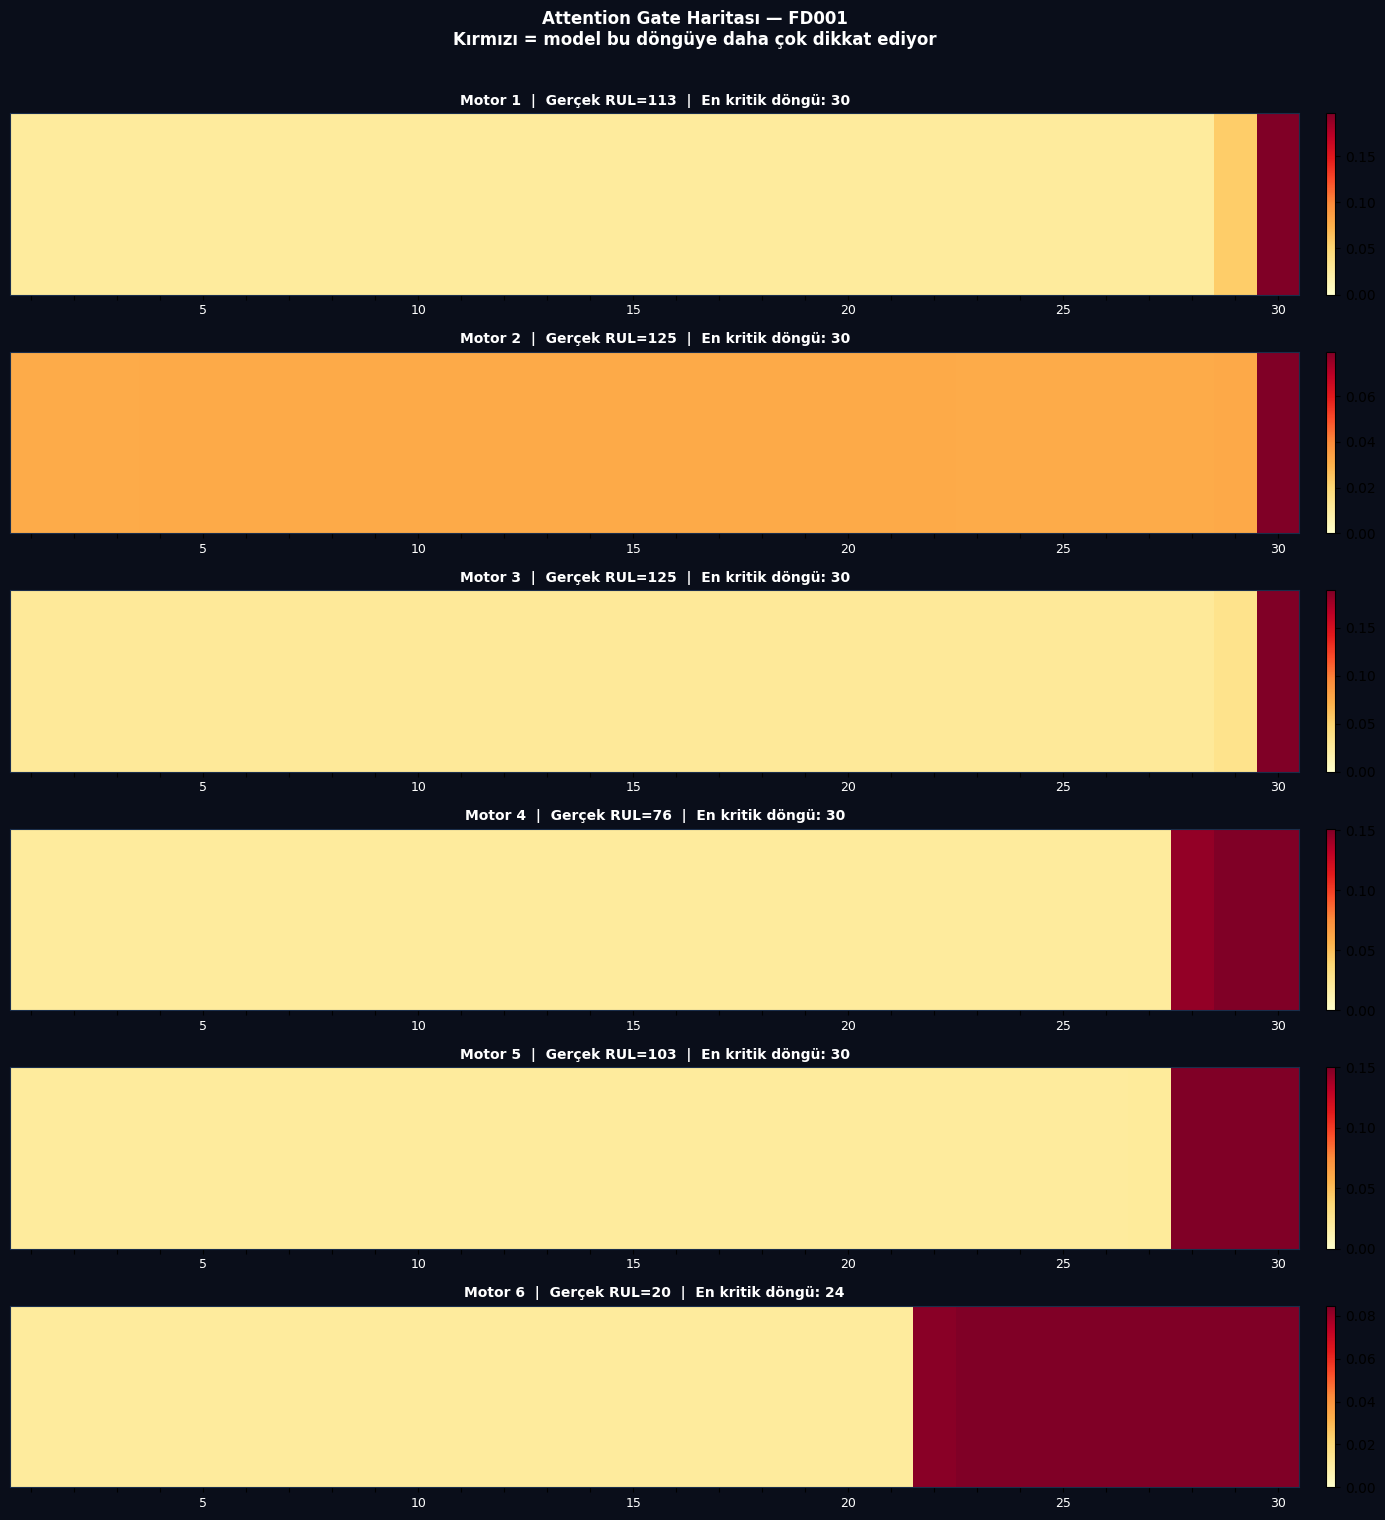

  ✓ Attention haritası: /content/drive/MyDrive/cmapss_asama2b/FD001/attention_heatmap_FD001.png

  FD001 — AŞAMA 2B ÖZET
  A1 en iyi                             13.104
  ─────────────────────────────────────────────────────────────────
  Model                                   RMSE       R²        Score     Ep
  ─────────────────────────────────────────────────────────────────
  BiLSTM+Attention                      13.261   0.8010      44298.5     23
  Transformer (A1)                      12.970   0.8096      42638.7     15
  Basit α=0.40                          12.785   0.8150      40296.6      —
  GRU Meta ★                            12.762   0.8157      38549.3      3 ← EN İYİ

  A1→2B: 13.104→12.762 (%2.6 iyileşme ✓)


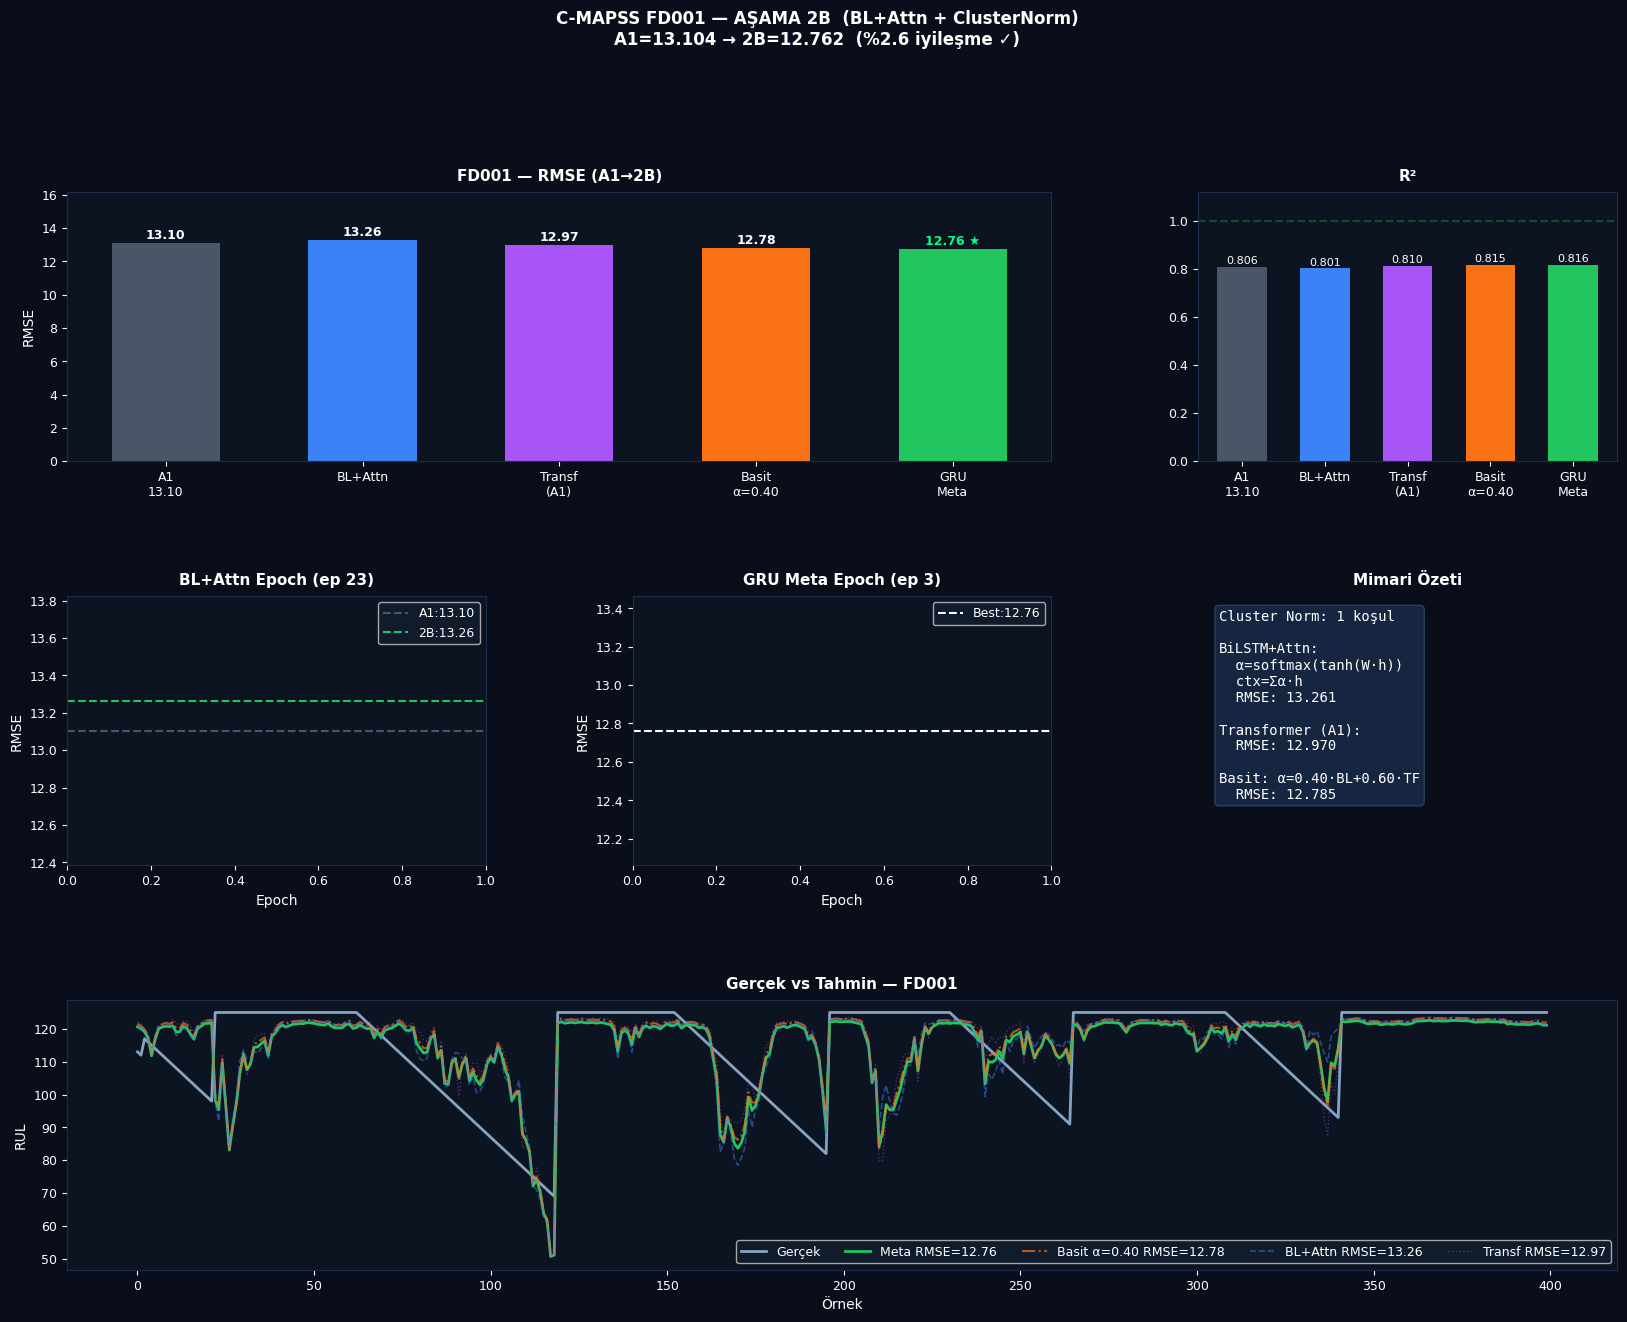

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama2b/FD001/asama2b_FD001.png

#################################################################
#  FD001 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 2B — FD002  (ClusterNorm)
#################################################################
  [FD002] Cluster norm (6 koşul)...
  Cluster dağılımı: C0=13458, C1=8122, C2=8002, C3=8044, C4=8096, C5=8037
  [FD002] Train: (46219, 30, 23) | Test: (26505, 30, 23)

[ADIM 1] BiLSTM+Attention...

  [BL+Attn[FD002]] Checkpoint → yükleniyor
  ✓ bilstm_attn_FD002: RMSE=16.107  R²=0.7299

[ADIM 2] Transformer — A2B'de yeniden eğitiliyor...

  [Transformer[FD002]] Checkpoint → yükleniyor
  ✓ transformer_FD002: RMSE=15.665  R²=0.7445

[ADIM 3] OOF tahminleri...

  [BL+Attn] OOF cache → yükleniyor
  OOF RMSE: 15.894

  [Transformer] OOF cache → yükleniyor
  OOF RMSE: 16.664

[ADIM 4] GRU Meta...

  [Met

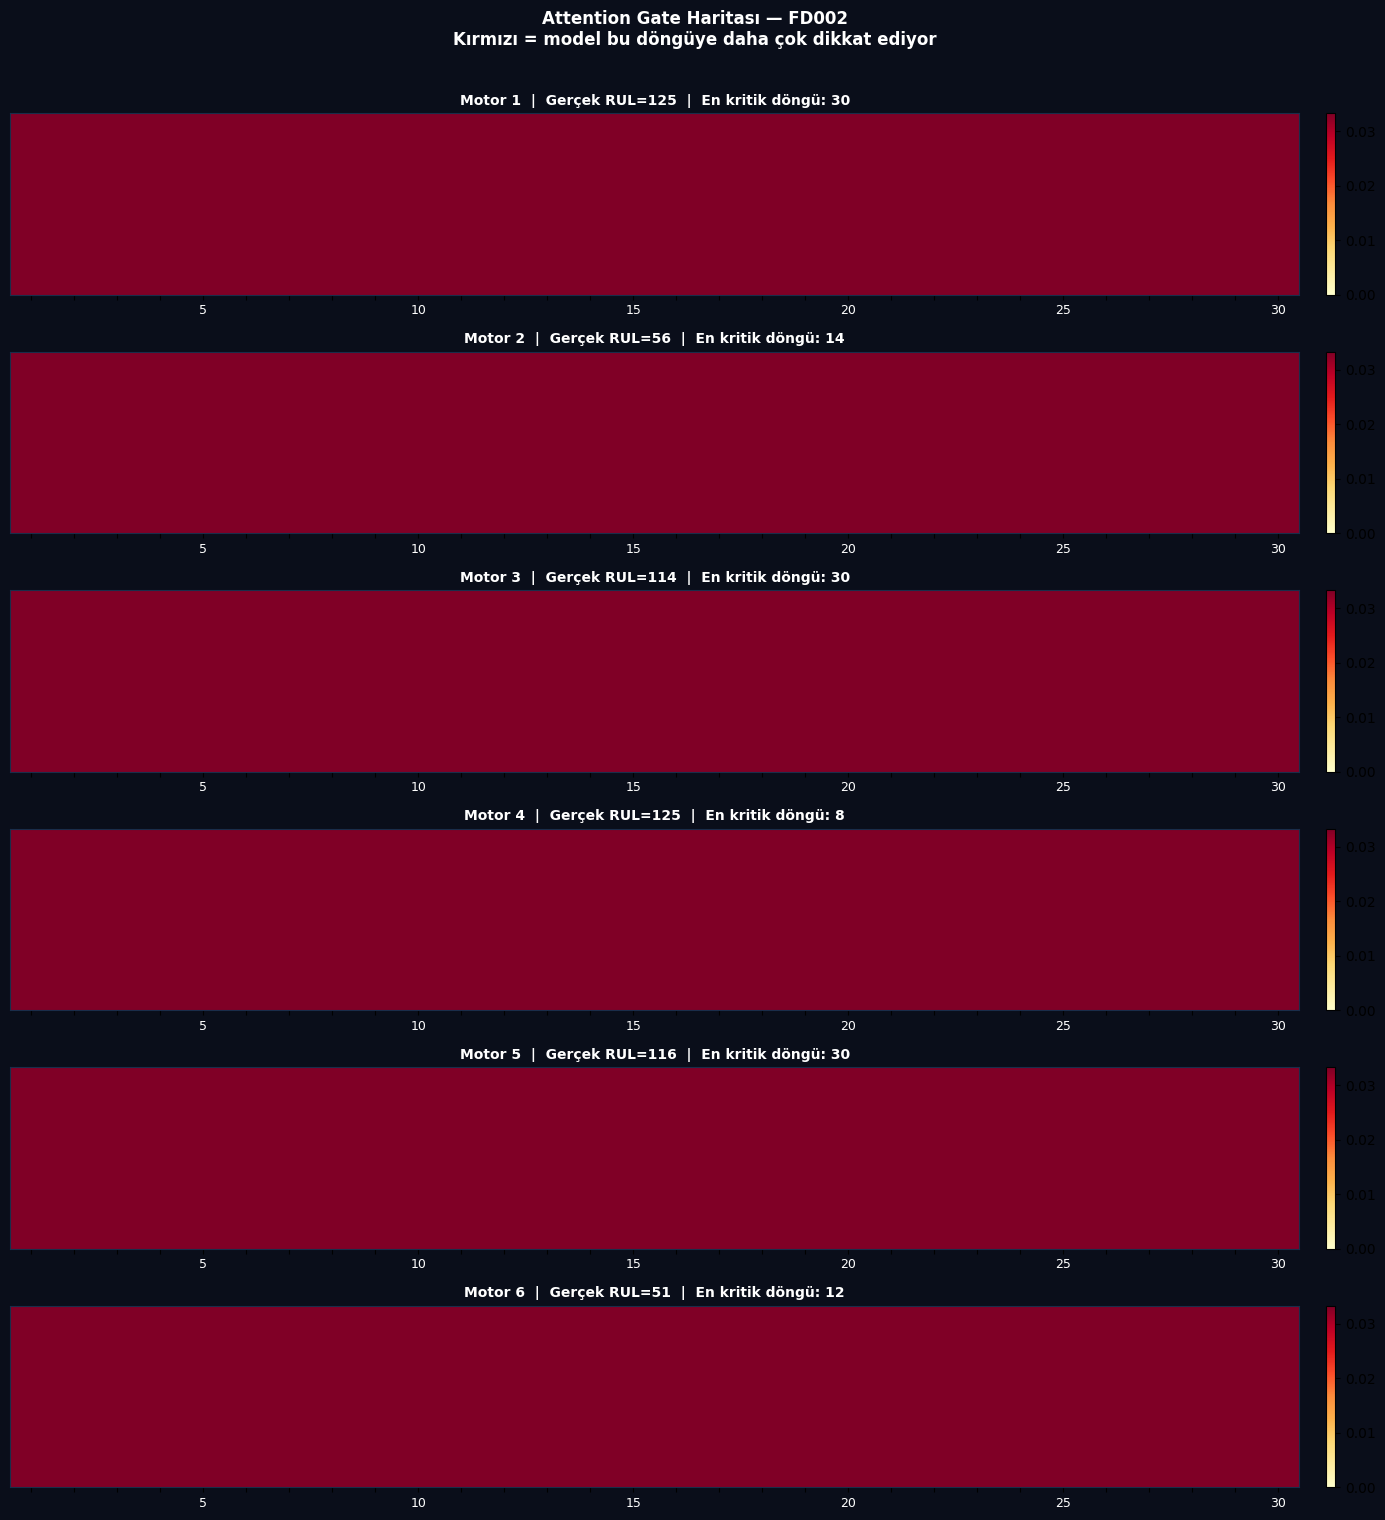

  ✓ Attention haritası: /content/drive/MyDrive/cmapss_asama2b/FD002/attention_heatmap_FD002.png

  FD002 — AŞAMA 2B ÖZET
  A1 en iyi                             16.696
  ─────────────────────────────────────────────────────────────────
  Model                                   RMSE       R²        Score     Ep
  ─────────────────────────────────────────────────────────────────
  BiLSTM+Attention                      16.107   0.7299     214637.1     10
  Transformer (A1)                      15.665   0.7445     199759.8      6
  Basit α=0.35                          15.420   0.7525     184579.9      — ← EN İYİ
  GRU Meta ★                            15.535   0.7487     168826.1     14

  A1→2B: 16.696→15.420 (%7.6 iyileşme ✓)


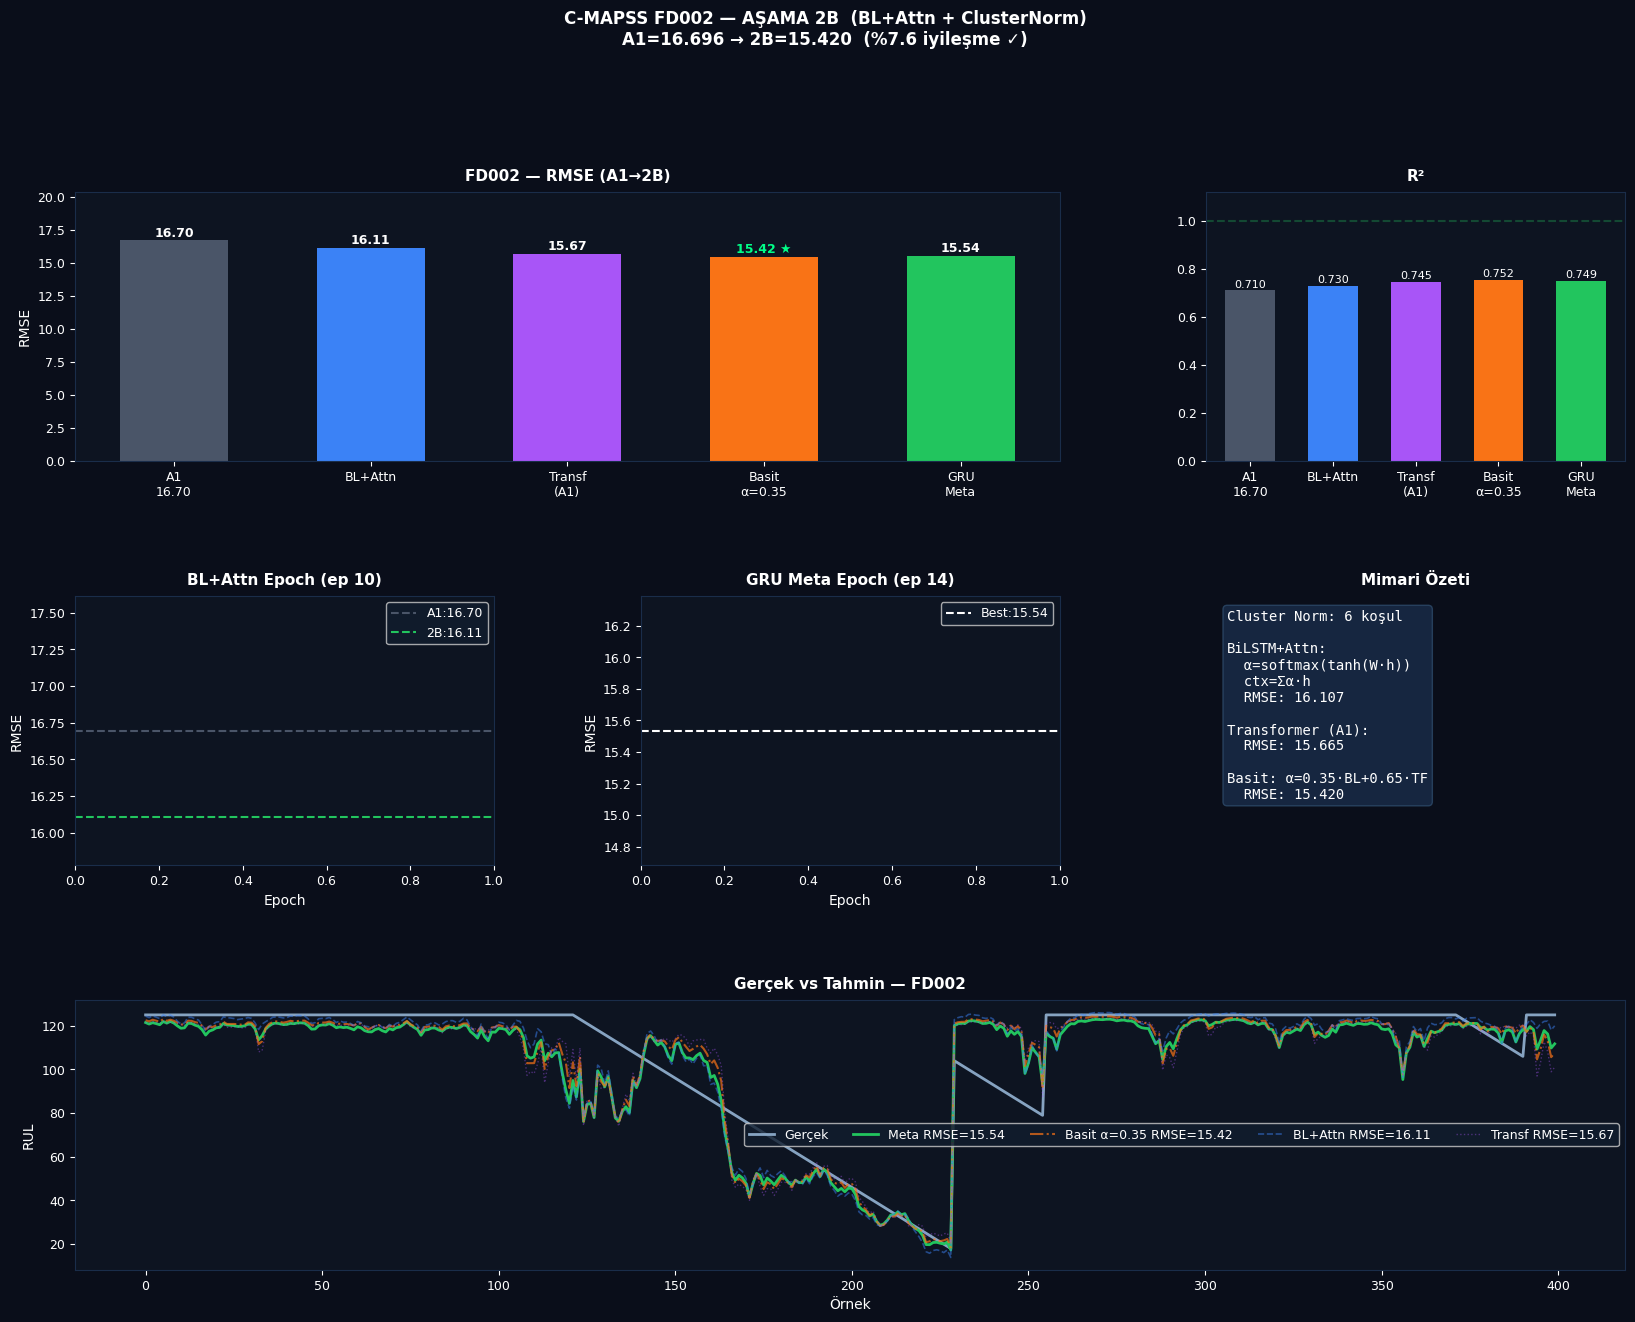

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama2b/FD002/asama2b_FD002.png

#################################################################
#  FD002 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 2B — FD003  (Tek koşul)
#################################################################
  [FD003] Cluster norm (1 koşul)...
  [FD003] Train: (21820, 30, 16) | Test: (13696, 30, 16)

[ADIM 1] BiLSTM+Attention...

  [BL+Attn[FD003]] Checkpoint → yükleniyor
  ✓ bilstm_attn_FD003: RMSE=11.356  R²=0.8175

[ADIM 2] Transformer — A2B'de yeniden eğitiliyor...

  [Transformer[FD003]] Checkpoint → yükleniyor
  ✓ transformer_FD003: RMSE=10.607  R²=0.8408

[ADIM 3] OOF tahminleri...

  [BL+Attn] OOF cache → yükleniyor
  OOF RMSE: 11.774

  [Transformer] OOF cache → yükleniyor
  OOF RMSE: 11.542

[ADIM 4] GRU Meta...

  [Meta] Checkpoint → yükleniyor
  ✓ meta_FD003: RMSE=10.366  R²=0.8480
  Meta: RM

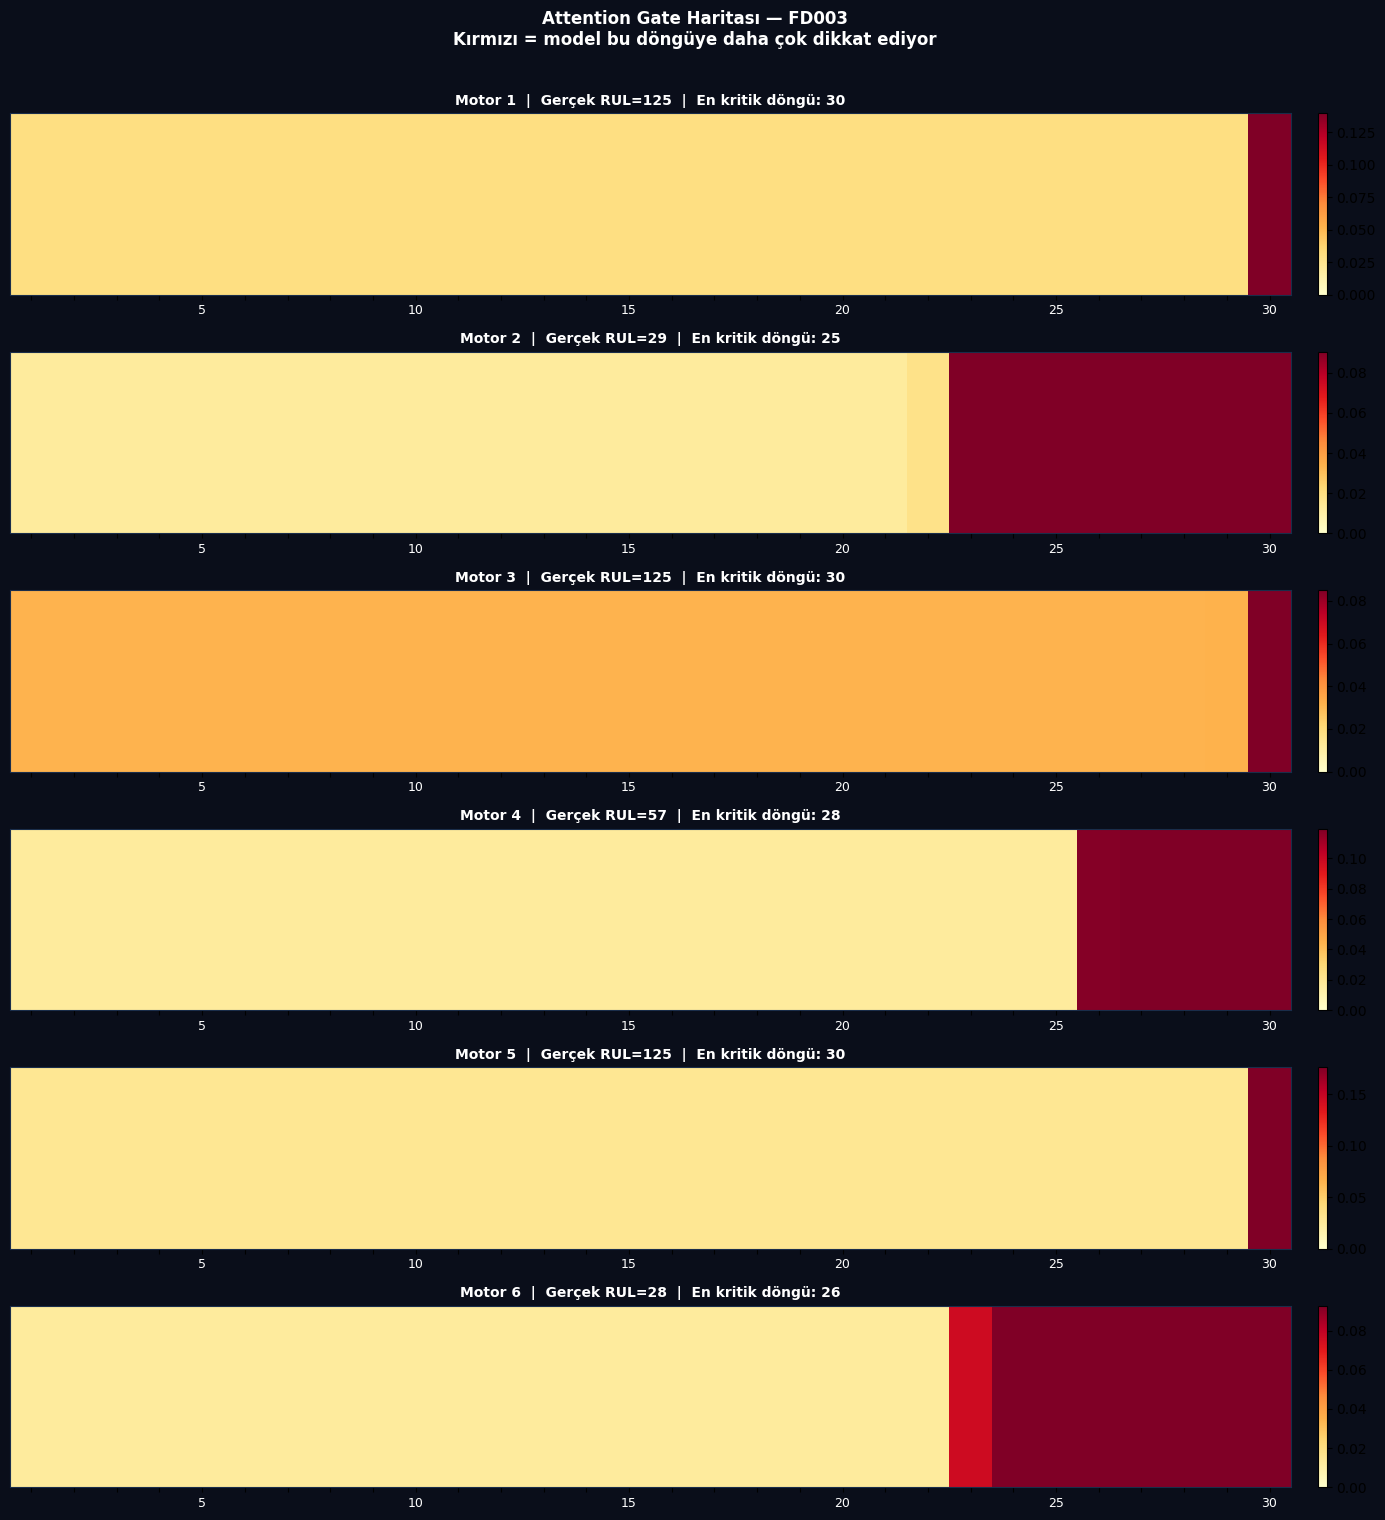

  ✓ Attention haritası: /content/drive/MyDrive/cmapss_asama2b/FD003/attention_heatmap_FD003.png

  FD003 — AŞAMA 2B ÖZET
  A1 en iyi                             10.431
  ─────────────────────────────────────────────────────────────────
  Model                                   RMSE       R²        Score     Ep
  ─────────────────────────────────────────────────────────────────
  BiLSTM+Attention                      11.356   0.8175      42174.9     19
  Transformer (A1)                      10.607   0.8408      38493.3     27
  Basit α=0.35                          10.346   0.8486      34932.7      — ← EN İYİ
  GRU Meta ★                            10.366   0.8480      34265.3     11

  A1→2B: 10.431→10.346 (%0.8 iyileşme ✓)


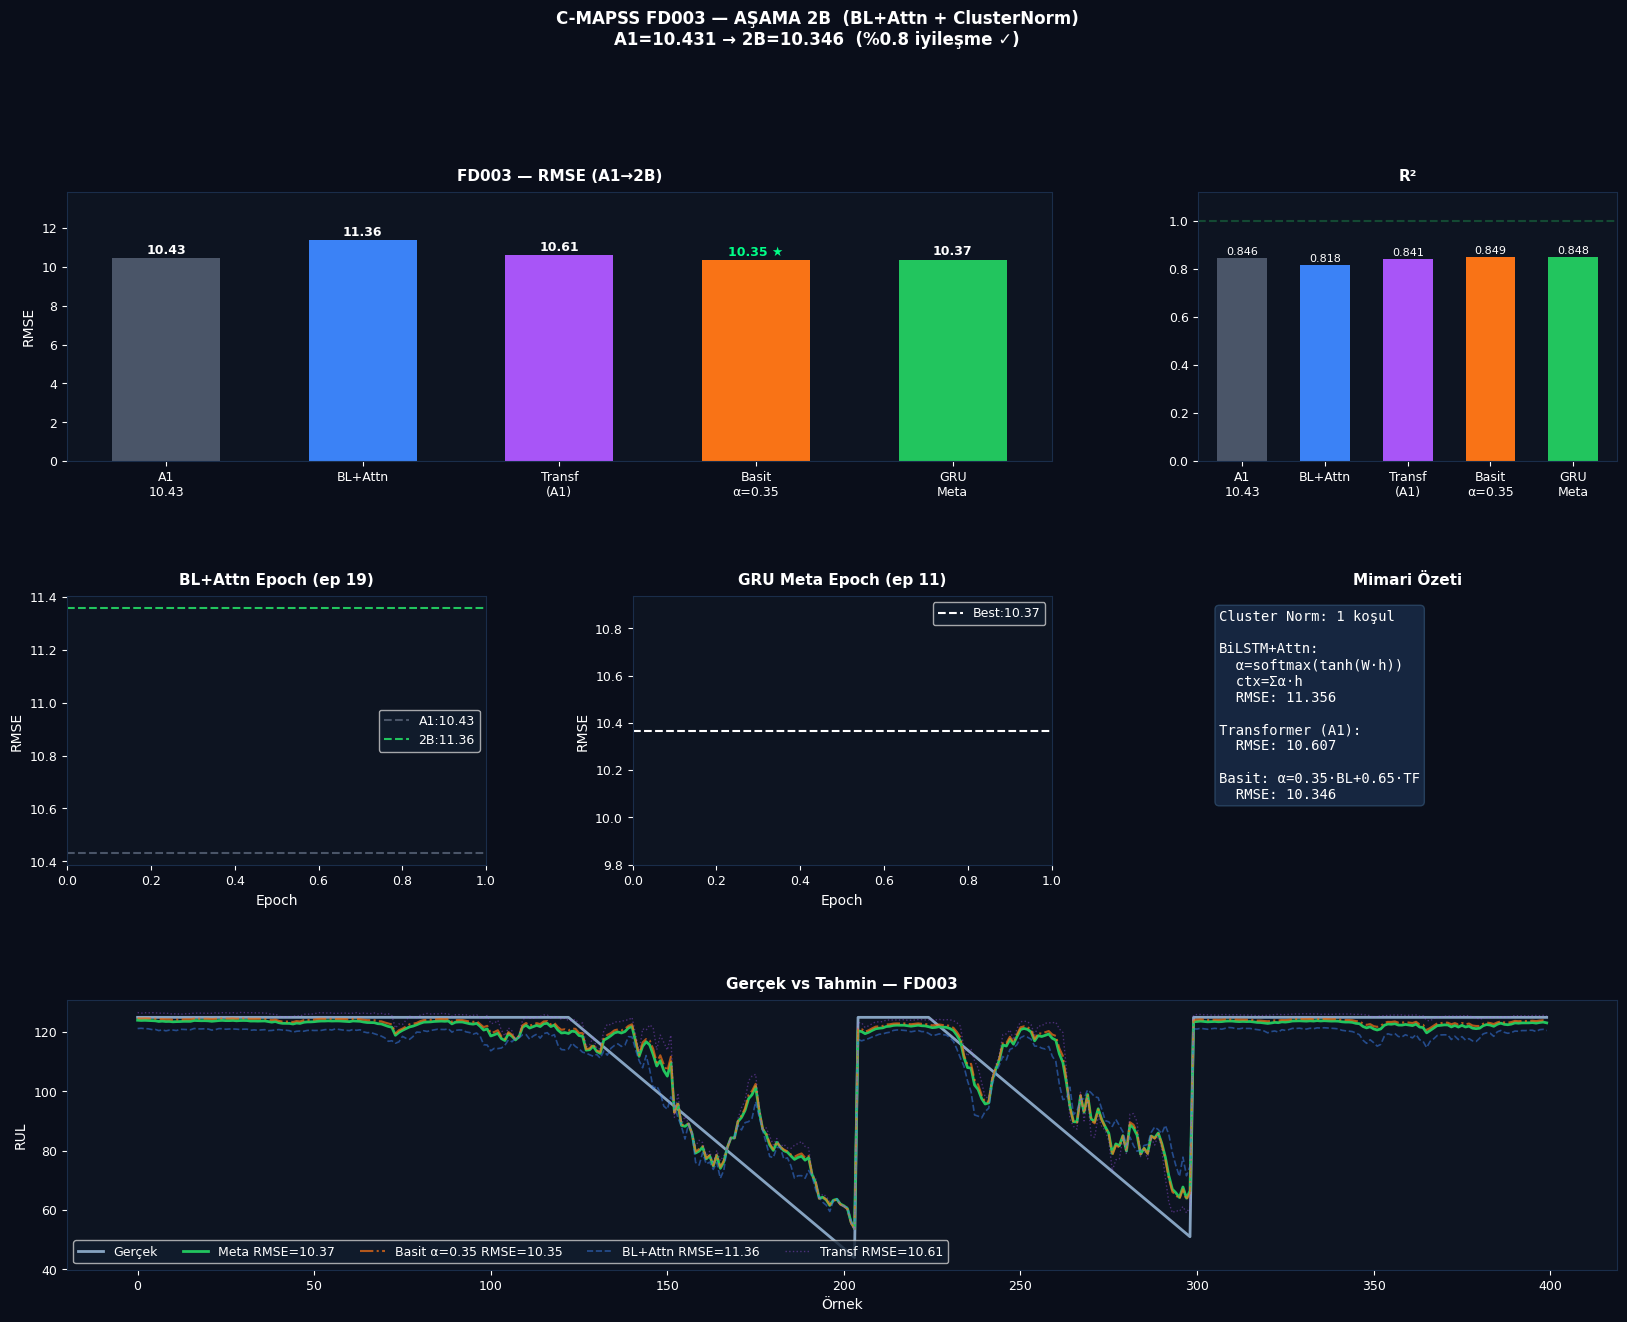

  ✓ Grafik: /content/drive/MyDrive/cmapss_asama2b/FD003/asama2b_FD003.png

#################################################################
#  FD003 TAMAMLANDI
#################################################################

#################################################################
#  AŞAMA 2B — FD004  (ClusterNorm)
#################################################################
  [FD004] Cluster norm (6 koşul)...
  Cluster dağılımı: C0=15395, C1=9224, C2=9139, C3=9091, C4=9238, C5=9162
  [FD004] Train: (54028, 30, 23) | Test: (34081, 30, 23)

[ADIM 1] BiLSTM+Attention...

  [BL+Attn[FD004]] Checkpoint → yükleniyor
  ✓ bilstm_attn_FD004: RMSE=14.721  R²=0.7095

[ADIM 2] Transformer — A2B'de yeniden eğitiliyor...

  [Transformer[FD004]] Checkpoint → yükleniyor


In [ ]:
all_results=[]

for SUBSET in ['FD001','FD002','FD003','FD004']:

    print(f"\n{'#'*65}")
    print(f"#  AŞAMA 2B — {SUBSET}  "
          f"({'ClusterNorm' if N_CLUSTERS[SUBSET]>1 else 'Tek koşul'})")
    print(f"{'#'*65}")

    data=load_and_prepare(SUBSET)
    N=data['n_feat']
    A1_CKPT =os.path.join(A1_CKPT_ROOT, SUBSET)
    A2B_CKPT=os.path.join(A2B_CKPT_ROOT,SUBSET)
    SAVE_DIR=os.path.join(SAVE_ROOT,SUBSET)
    os.makedirs(A2B_CKPT,exist_ok=True); os.makedirs(SAVE_DIR,exist_ok=True)

    # ADIM 1 — BiLSTM+Attention
    print(f"\n[ADIM 1] BiLSTM+Attention...")
    bl_m,bl_p,bl_mdl=train_base(
        BiLSTMAttention(N),data,max_ep=200,lr=1e-3,patience=15,
        name=f'BL+Attn[{SUBSET}]',ck_name='bilstm_attn',ck_dir=A2B_CKPT,force=False)

    # ADIM 2 — Transformer (Aşama 2B'de yeniden eğitiliyor)
    print(f"\n[ADIM 2] Transformer — A2B'de yeniden eğitiliyor...")
    tf_m,tf_p,tf_mdl=train_base(
        TransformerRUL(N),data,max_ep=200,lr=5e-4,patience=15,
        name=f'Transformer[{SUBSET}]',ck_name='transformer',ck_dir=A2B_CKPT,force=False)

    # ADIM 3 — OOF
    print(f"\n[ADIM 3] OOF tahminleri...")
    oof_bl=get_oof(BiLSTMAttention,{'n_feat':N},data,
                   n_splits=5,max_ep=150,lr=1e-3,patience=15,name='BL+Attn',
                   ck_name='bilstm_attn',ck_dir=A2B_CKPT,force=False)
    oof_tf=get_oof(TransformerRUL,{'n_feat':N},data,
                   n_splits=5,max_ep=150,lr=5e-4,patience=15,name='Transformer',
                   ck_name='transformer',ck_dir=A2B_CKPT,force=False)

    # ADIM 4 — GRU Meta
    print(f"\n[ADIM 4] GRU Meta...")
    meta_m,meta_p=train_meta(
        GRUMetaModel(N),data,oof_bl,oof_tf,bl_p,tf_p,
        max_ep=100,lr=5e-4,patience=20,ck_name='meta',ck_dir=A2B_CKPT,force=False)

    # ADIM 5 — Attention haritası
    print(f"\n[ADIM 5] Attention haritası...")
    plot_attention_heatmap(bl_mdl,data,SUBSET,SAVE_DIR,n=6)

    # Basit Ensemble
    best_a,best_r=0.5,float('inf')
    for a in np.arange(0,1.01,0.05):
        r=float(np.sqrt(mean_squared_error(data['y_te'],a*bl_p+(1-a)*tf_p)))
        if r<best_r: best_r=r; best_a=a
    si_p=best_a*bl_p+(1-best_a)*tf_p
    si_m=get_metrics(data['y_te'],si_p)

    # Özet
    best_new=min(bl_m['RMSE'],tf_m['RMSE'],si_m['RMSE'],meta_m['RMSE'])
    a1=A1_BEST.get(SUBSET,{}).get('best_rmse'); iy=((a1-best_new)/a1*100) if a1 else 0

    print(f"\n{'='*70}\n  {SUBSET} — AŞAMA 2B ÖZET\n{'='*70}")
    if a1: print(f"  {'A1 en iyi':<36} {a1:>7.3f}")
    print(f"  {'─'*65}")
    print(f"  {'Model':<36} {'RMSE':>7} {'R²':>8} {'Score':>12} {'Ep':>6}")
    print(f"  {'─'*65}")
    for lbl,m in [('BiLSTM+Attention',bl_m),('Transformer (A1)',tf_m),
                   (f'Basit α={best_a:.2f}',si_m),('GRU Meta ★',meta_m)]:
        ep=str(m.get('best_ep','—'))
        mk=" ← EN İYİ" if abs(m['RMSE']-best_new)<0.001 else ""
        print(f"  {lbl:<36} {m['RMSE']:>7.3f} {m['R2']:>8.4f} {m['Score']:>12.1f} {ep:>6}{mk}")
    if a1: print(f"\n  A1→2B: {a1:.3f}→{best_new:.3f} (%{iy:.1f} {'iyileşme ✓' if iy>0 else 'fark'})")

    plot_results(SUBSET,data,bl_m,tf_m,si_m,meta_m,bl_p,tf_p,si_p,meta_p,best_a,SAVE_DIR)

    rows=[]
    for lbl,m in [('BL+Attn',bl_m),('Transformer A1',tf_m),(f'Basit a={best_a}',si_m),('GRU Meta',meta_m)]:
        rows.append({'Subset':SUBSET,'Model':lbl,'RMSE':round(m['RMSE'],4),
                     'R2':round(m['R2'],4),'Score':round(m['Score'],1),'Best_Ep':m.get('best_ep','—')})
    pd.DataFrame(rows).to_csv(os.path.join(SAVE_DIR,f'asama2b_{SUBSET}.csv'),index=False)

    all_results.append({'Subset':SUBSET,'A1_best':a1,
        'BL_Attn':round(bl_m['RMSE'],3),'Transformer':round(tf_m['RMSE'],3),
        'Simple':round(si_m['RMSE'],3),'Meta':round(meta_m['RMSE'],3),
        'Best_2B':round(best_new,3),'Iy_A1':round(iy,1),
        'ClusterNorm':N_CLUSTERS[SUBSET]>1})

    del bl_mdl,tf_mdl; torch.cuda.empty_cache()
    print(f"\n{'#'*65}\n#  {SUBSET} TAMAMLANDI\n{'#'*65}")

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 12 — Genel Özet                          ║
# ╚══════════════════════════════════════════════════╝

df=pd.DataFrame(all_results)
print(f"\n{'='*80}\n  AŞAMA 2B — TÜM SUBSETLER ÖZET\n{'='*80}")
print(f"  {'Sub':<6} {'A1':>7} {'BL+Attn':>9} {'Transf':>8} {'Basit':>8} {'Meta':>8} {'EN İYİ':>8} {'A1→2B':>8} {'CL':>4}")
print(f"  {'─'*75}")
for _,r in df.iterrows():
    best=r['Best_2B']
    bl=f"{r['BL_Attn']:.3f}"+(' ★' if r['BL_Attn']==best else '')
    tf=f"{r['Transformer']:.3f}"+(' ★' if r['Transformer']==best else '')
    si=f"{r['Simple']:.3f}"+(' ★' if r['Simple']==best else '')
    me=f"{r['Meta']:.3f}"+(' ★' if r['Meta']==best else '')
    a1=f"{r['A1_best']:.3f}" if r['A1_best'] else '—'
    iy=f"%{r['Iy_A1']:.1f}"+(' ✓' if r['Iy_A1']>0 else '')
    cn="✓" if r['ClusterNorm'] else "—"
    print(f"  {r['Subset']:<6} {a1:>7} {bl:>9} {tf:>8} {si:>8} {me:>8} {best:>8.3f} {iy:>8} {cn:>4}")

df.to_csv(f'{SAVE_ROOT}/asama2b_ozet.csv',index=False)
print(f"\n✓ Özet: {SAVE_ROOT}/asama2b_ozet.csv")
print(f"\n{'='*65}\n  AŞAMA 2B TAMAMLANDI\n  Sıradaki: Aşama 2C — SHAP\n{'='*65}")


  AŞAMA 2B — TÜM SUBSETLER ÖZET
  Sub         A1   BL+Attn   Transf    Basit     Meta   EN İYİ    A1→2B   CL
  ───────────────────────────────────────────────────────────────────────────
  FD001   13.104    13.261   12.970   12.785 12.762 ★   12.762   %2.6 ✓    —
  FD002   16.696    16.107   15.665 15.420 ★   15.535   15.420   %7.6 ✓    ✓
  FD003   10.431    11.356   10.607 10.346 ★   10.366   10.346   %0.8 ✓    —
  FD004   16.239    14.721   14.299 13.877 ★   13.885   13.877  %14.5 ✓    ✓

✓ Özet: /content/drive/MyDrive/cmapss_asama2b/asama2b_ozet.csv

  AŞAMA 2B TAMAMLANDI
  Sıradaki: Aşama 2C — SHAP


In [ ]:
import pandas as pd
import os

SAVE_ROOT = '/content/drive/MyDrive/cmapss_asama2b'
SUBSETS = ['FD001', 'FD002', 'FD003', 'FD004']

# Initialize a list to store the score results
score_results = []

for subset in SUBSETS:
    subset_save_dir = os.path.join(SAVE_ROOT, subset)
    csv_path = os.path.join(subset_save_dir, f'asama2b_{subset}.csv')

    if os.path.exists(csv_path):
        df_subset = pd.read_csv(csv_path)
        # Extract scores for each model
        bl_score = df_subset[df_subset['Model'] == 'BL+Attn']['Score'].iloc[0]
        tf_score = df_subset[df_subset['Model'] == 'Transformer A1']['Score'].iloc[0]
        si_score = df_subset[df_subset['Model'].str.startswith('Basit a=')]['Score'].iloc[0]
        meta_score = df_subset[df_subset['Model'] == 'GRU Meta']['Score'].iloc[0]

        # Find the best score (lower is better for NASA score)
        current_scores = [bl_score, tf_score, si_score, meta_score]
        best_score_subset = min(current_scores)

        score_results.append({
            'Subset': subset,
            'BL+Attn_Score': bl_score,
            'Transformer_Score': tf_score,
            'Simple_Score': si_score,
            'Meta_Score': meta_score,
            'Best_Score': best_score_subset
        })
    else:
        print(f"Warning: CSV not found for {subset} at {csv_path}")

# Create a DataFrame from the collected results
scores_df = pd.DataFrame(score_results)

print(f"\n{'='*80}")
print(f"  AŞAMA 2B — TÜM SUBSETLER NASA SCORE ÖZET")
print(f"{'='*80}")

print(f"  {'Sub':<6} {'BL+Attn':>12} {'Transf':>12} {'Basit':>12} {'Meta':>12} {'EN İYİ':>12}")
print(f"  {'─'*75}")
for _, r in scores_df.iterrows():
    best = r['Best_Score']
    bl = f"{r['BL+Attn_Score']:>12.1f}" + (' ★' if r['BL+Attn_Score'] == best else '')
    tf = f"{r['Transformer_Score']:>12.1f}" + (' ★' if r['Transformer_Score'] == best else '')
    si = f"{r['Simple_Score']:>12.1f}" + (' ★' if r['Simple_Score'] == best else '')
    me = f"{r['Meta_Score']:>12.1f}" + (' ★' if r['Meta_Score'] == best else '')

    print(f"  {r['Subset']:<6} {bl} {tf} {si} {me} {r['Best_Score']:>12.1f}")

output_csv_path = os.path.join(SAVE_ROOT, 'asama2b_nasa_score_ozet.csv')
scores_df.to_csv(output_csv_path, index=False)
print(f"\n✓ NASA Score Özeti: {output_csv_path}")



  AŞAMA 2B — TÜM SUBSETLER NASA SCORE ÖZET
  Sub         BL+Attn       Transf        Basit         Meta       EN İYİ
  ───────────────────────────────────────────────────────────────────────────
  FD001       44298.5      42638.7      40296.6      38549.3 ★      38549.3
  FD002      214637.1     199759.8     184579.9     168826.1 ★     168826.1
  FD003       42174.9      38493.3      34932.7      34265.3 ★      34265.3
  FD004      475080.8 ★     633188.3     494105.9     499873.8     475080.8

✓ NASA Score Özeti: /content/drive/MyDrive/cmapss_asama2b/asama2b_nasa_score_ozet.csv
